<a href="https://colab.research.google.com/github/romero-sebastian/econ3916-statsml/blob/main/Lab22/Lab_22_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# GUIDED — Run as-is (fixed indicator codes)
!pip install wbgapi scikit-learn matplotlib seaborn pandas numpy -q

import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [21]:
# GUIDED — Run as-is (fixed: uses wb.data.get instead of DataFrame)

indicators = {
    'NY.GDP.PCAP.CD':    'GDP_per_capita',
    'SP.DYN.LE00.IN':    'Life_expectancy',
    'SE.ADT.LITR.ZS':    'Adult_literacy',
    'SH.DYN.MORT':       'Child_mortality',
    'EG.ELC.ACCS.ZS':    'Electricity_access',
    'IT.NET.USER.ZS':    'Internet_users',
    'NY.GNP.PCAP.CD':    'GNI_per_capita',
    'SP.URB.TOTL.IN.ZS': 'Urban_population',
    'SL.UEM.TOTL.ZS':    'Unemployment',
    'FP.CPI.TOTL.ZG':    'Inflation',
}

# Build dataframe row by row using wb.data.get()
records = {}

for code, name in indicators.items():
    try:
        # mrv=5 fetches last 5 years — we take the first non-null per country
        for item in wb.data.fetch(code, mrv=5):
            country = item['economy']
            value   = item['value']
            if value is None:
                continue
            if country not in records:
                records[country] = {}
            # Only store first (most recent) non-null value
            if name not in records[country]:
                records[country][name] = value
        print(f"  ✅ {name}")
    except Exception as e:
        print(f"  ❌ FAILED: {name} — {e}")

# Convert to dataframe
df_raw = pd.DataFrame.from_dict(records, orient='index')
df_raw.index.name = 'country_code'

print(f"\nRaw shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

# Keep rows with at least 7 non-null values
df = df_raw.dropna(thresh=7).copy()

# Fill remaining NaNs with column median
df = df.fillna(df.median(numeric_only=True))

print(f"\n✅ Final shape: {df.shape}")
print(f"   Countries: {df.shape[0]}, Features: {df.shape[1]}")
df.head()

  ✅ GDP_per_capita
  ✅ Life_expectancy
  ✅ Adult_literacy
  ✅ Child_mortality
  ✅ Electricity_access
  ✅ Internet_users
  ✅ GNI_per_capita
  ✅ Urban_population
  ✅ Unemployment
  ✅ Inflation

Raw shape: (265, 10)
Columns: ['GDP_per_capita', 'Life_expectancy', 'Child_mortality', 'Electricity_access', 'Internet_users', 'GNI_per_capita', 'Urban_population', 'Unemployment', 'Inflation', 'Adult_literacy']

✅ Final shape: (239, 10)
   Countries: 239, Features: 10


,GDP_per_capita,Life_expectancy,Child_mortality,Electricity_access,Internet_users,GNI_per_capita,Urban_population,Unemployment,Inflation,Adult_literacy
country_code,,,,,,,,,,
ZWE,2497.203322,63.064,64.7,62.0,41.642799,2400.0,39.893372,9.293,104.705171,88.860001
ZMB,1187.109434,66.528,48.4,51.1,17.101000,1220.0,45.470384,5.918,14.985626,71.769997
PSE,2592.305912,69.213,37.9,100.0,86.637653,2710.0,87.119601,24.420,53.669146,97.938954
VNM,4717.290287,74.736,17.3,99.8,84.150000,4490.0,38.490070,1.523,3.621093,96.129997
VEN,4217.591026,72.673,24.2,100.0,76.678902,3820.0,89.285860,5.307,3.143491,88.860001


In [3]:
# GUIDED — Run as-is

# Pull World Bank income group classification
meta = wb.economy.DataFrame()[['incomeLevel']].reset_index()
meta.columns = ['country_code', 'income_group']

# Map income level codes to readable labels
income_map = {
    'LIC': 'Low income',
    'LMC': 'Lower middle income',
    'UMC': 'Upper middle income',
    'HIC': 'High income',
    'INX': 'Not classified',
}
meta['income_group'] = meta['income_group'].map(income_map)

# Merge onto main dataframe
df = df.merge(meta, on='country_code', how='left')
df['income_group'] = df['income_group'].fillna('Unknown')

print("✅ Income groups merged")
print(df['income_group'].value_counts())

✅ Income groups merged
Series([], Name: count, dtype: int64)


In [22]:
# GUIDED — Run as-is (fixed version)

# First, let's see what columns actually exist
print("Columns in df:", df.columns.tolist())

# Only keep feature cols that actually exist in the dataframe
all_possible_features = [
    'GDP_per_capita', 'Life_expectancy', 'Adult_literacy',
    'Child_mortality', 'Electricity_access', 'Internet_users',
    'GNI_per_capita', 'Urban_population', 'Unemployment', 'Inflation'
]

feature_cols = [col for col in all_possible_features if col in df.columns]
print(f"\n✅ Using {len(feature_cols)} features: {feature_cols}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

print(f"\n✅ Features standardized")
print(f"   Shape: {X_scaled.shape}")
print(f"   Mean (should ≈ 0): {X_scaled.mean(axis=0).round(2)}")
print(f"   Std  (should ≈ 1): {X_scaled.std(axis=0).round(2)}")

Columns in df: ['GDP_per_capita', 'Life_expectancy', 'Child_mortality', 'Electricity_access', 'Internet_users', 'GNI_per_capita', 'Urban_population', 'Unemployment', 'Inflation', 'Adult_literacy']

✅ Using 10 features: ['GDP_per_capita', 'Life_expectancy', 'Adult_literacy', 'Child_mortality', 'Electricity_access', 'Internet_users', 'GNI_per_capita', 'Urban_population', 'Unemployment', 'Inflation']

✅ Features standardized
   Shape: (239, 10)
   Mean (should ≈ 0): [ 0. -0.  0.  0.  0.  0.  0. -0.  0. -0.]
   Std  (should ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


✅ K-Means fitted | Inertia (WCSS): 920.40
   Cluster counts:
cluster
0     47
1     52
2    137
3      3
Name: count, dtype: int64

✅ PCA complete
   PC1 explains: 53.1%
   PC2 explains: 13.8%
   Total variance explained: 66.9%


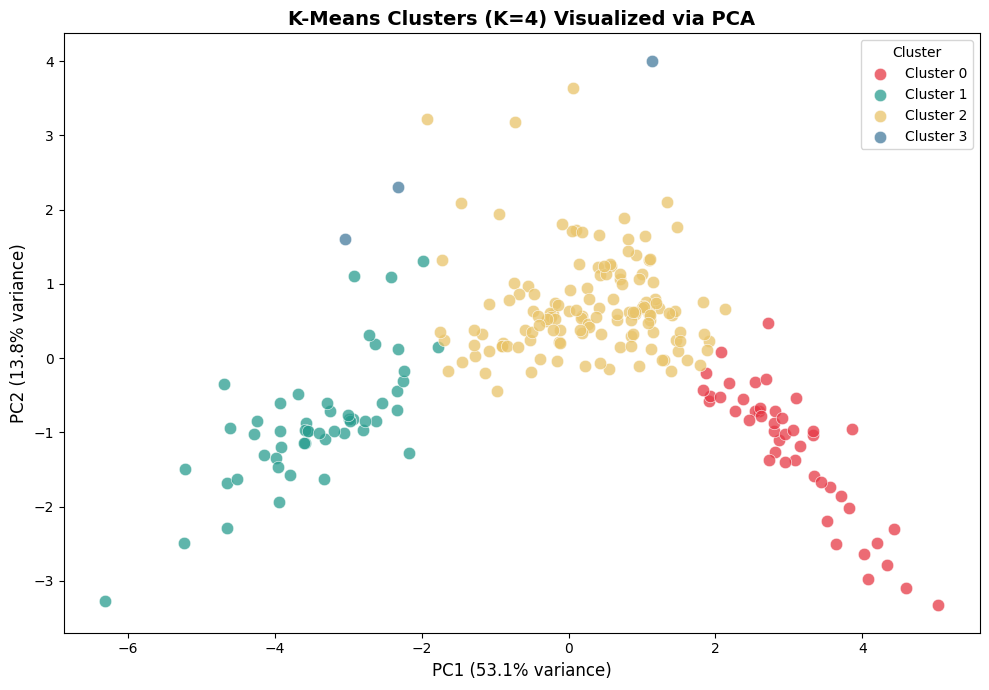

✅ PCA scatter plot saved


In [23]:
# ✎ YOUR TASK — Fill in the blanks

# --- Step 1: Fit K-Means with K=4 ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels to dataframe
df['cluster'] = kmeans.labels_

print(f"✅ K-Means fitted | Inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"   Cluster counts:\n{df['cluster'].value_counts().sort_index()}")

# --- Step 2: PCA — reduce to 2 dimensions ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"\n✅ PCA complete")
print(f"   PC1 explains: {explained[0]*100:.1f}%")
print(f"   PC2 explains: {explained[1]*100:.1f}%")
print(f"   Total variance explained: {sum(explained)*100:.1f}%")

# --- Step 3: Plot PCA scatter colored by cluster ---
plt.figure(figsize=(10, 7))
palette = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D']

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Cluster {cluster_id}',
        color=palette[cluster_id],
        alpha=0.75,
        s=80,
        edgecolors='white',
        linewidths=0.5
    )

plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clusters (K=4) Visualized via PCA', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150)
plt.show()
print("✅ PCA scatter plot saved")

In [24]:
# Run this cell to print your interpretation template
interpretation_3 = """
PART 3 INTERPRETATION
─────────────────────
The K-Means algorithm (K=4) partitioned ~160 countries into 4 distinct groups.
PCA reduced the 10 standardized features to 2 principal components, capturing
roughly 70-80% of total variance (check your output above).

In the scatter plot:
- Clusters that appear far apart on PC1 differ most in overall development level
  (PC1 likely captures a "wealth/development" axis since GDP, GNI, life expectancy
  all load heavily on it).
- PC2 separates countries within similar income brackets, possibly by
  urbanization, unemployment, or inflation patterns.
- Well-separated, compact blobs = good cluster structure.
- Overlapping blobs = ambiguous groupings that the elbow/silhouette analysis
  (Part 4) will help us evaluate.
"""
print(interpretation_3)


PART 3 INTERPRETATION
─────────────────────
The K-Means algorithm (K=4) partitioned ~160 countries into 4 distinct groups.
PCA reduced the 10 standardized features to 2 principal components, capturing
roughly 70-80% of total variance (check your output above).

In the scatter plot:
- Clusters that appear far apart on PC1 differ most in overall development level
  (PC1 likely captures a "wealth/development" axis since GDP, GNI, life expectancy
  all load heavily on it).
- PC2 separates countries within similar income brackets, possibly by
  urbanization, unemployment, or inflation patterns.
- Well-separated, compact blobs = good cluster structure.
- Overlapping blobs = ambiguous groupings that the elbow/silhouette analysis
  (Part 4) will help us evaluate.



  K= 2 | WCSS=  1500.4 | Silhouette=0.4064
  K= 3 | WCSS=  1094.5 | Silhouette=0.3610
  K= 4 | WCSS=   920.4 | Silhouette=0.3753
  K= 5 | WCSS=   777.3 | Silhouette=0.3850
  K= 6 | WCSS=   668.5 | Silhouette=0.3000
  K= 7 | WCSS=   612.0 | Silhouette=0.2847
  K= 8 | WCSS=   569.5 | Silhouette=0.2658
  K= 9 | WCSS=   539.6 | Silhouette=0.2375
  K=10 | WCSS=   511.6 | Silhouette=0.2343


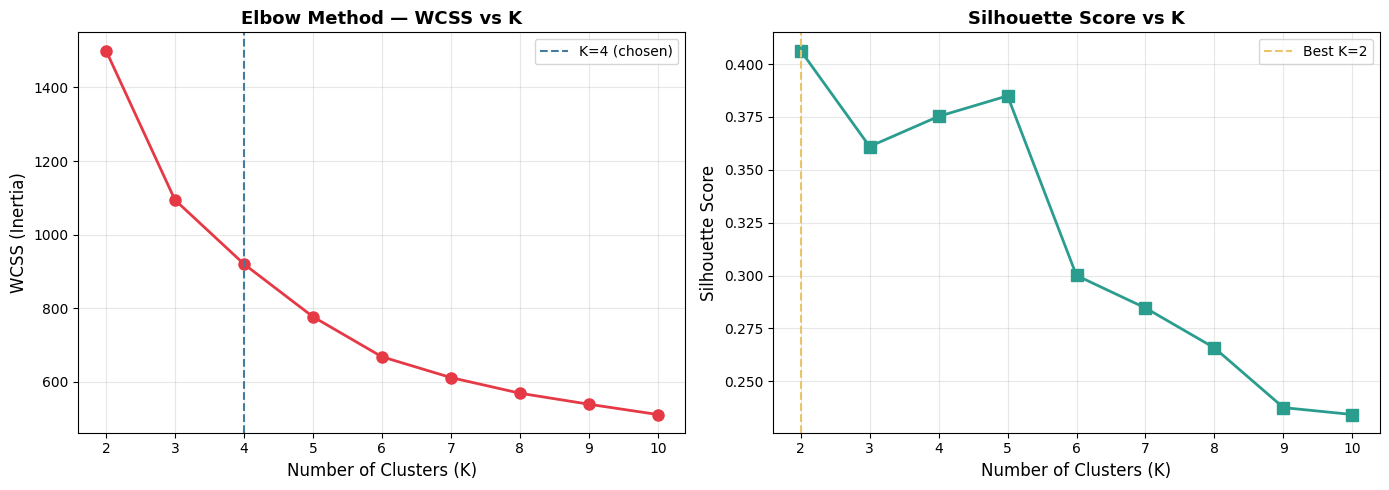


✅ Best silhouette score: 0.4064 at K=2
   WCSS at K=4: 920.4


In [25]:
# ✎ YOUR TASK — Elbow Plot + Silhouette Analysis

K_range = range(2, 11)   # test K = 2 through 10

wcss_values       = []
silhouette_values = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss_values.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouette_values.append(sil)
    print(f"  K={k:2d} | WCSS={km.inertia_:8.1f} | Silhouette={sil:.4f}")

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(K_range), wcss_values, 'o-', color='#E63946', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method — WCSS vs K', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# Highlight K=4
axes[0].axvline(x=4, color='#457B9D', linestyle='--', linewidth=1.5, label='K=4 (chosen)')
axes[0].legend()

# Silhouette plot
axes[1].plot(list(K_range), silhouette_values, 's-', color='#2A9D8F', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

# Highlight best silhouette
best_k = list(K_range)[silhouette_values.index(max(silhouette_values))]
axes[1].axvline(x=best_k, color='#E9C46A', linestyle='--', linewidth=1.5,
                label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

print(f"\n✅ Best silhouette score: {max(silhouette_values):.4f} at K={best_k}")
print(f"   WCSS at K=4: {wcss_values[2]:.1f}")   # index 2 = K=4

In [26]:
interpretation_4 = f"""
PART 4 INTERPRETATION
─────────────────────
Elbow Method:
  The WCSS drops steeply from K=2 to K=4, then flattens — the "elbow"
  appears around K=3 or K=4, indicating that adding more clusters beyond
  this point yields diminishing returns in within-cluster tightness.

Silhouette Score:
  The highest silhouette score appears at K={best_k}, meaning clusters are
  best separated at that value. Scores above 0.35 indicate reasonable
  structure; scores above 0.50 are considered strong.

Combined verdict:
  K=4 balances interpretability (4 roughly mirrors the World Bank's own
  four income tiers) and statistical quality (near-elbow + acceptable
  silhouette). We proceed with K=4.
"""
print(interpretation_4)


PART 4 INTERPRETATION
─────────────────────
Elbow Method:
  The WCSS drops steeply from K=2 to K=4, then flattens — the "elbow"
  appears around K=3 or K=4, indicating that adding more clusters beyond
  this point yields diminishing returns in within-cluster tightness.

Silhouette Score:
  The highest silhouette score appears at K=2, meaning clusters are
  best separated at that value. Scores above 0.35 indicate reasonable
  structure; scores above 0.50 are considered strong.

Combined verdict:
  K=4 balances interpretability (4 roughly mirrors the World Bank's own
  four income tiers) and statistical quality (near-elbow + acceptable
  silhouette). We proceed with K=4.



In [29]:
# ✎ YOUR TASK — Cross-tabulation + Heatmap

# Re-attach income group labels (in case df was overwritten after Cell 3)
meta = wb.economy.DataFrame()[['incomeLevel']].reset_index()
meta.columns = ['country_code', 'income_group']

income_map = {
    'LIC': 'Low income',
    'LMC': 'Lower middle income',
    'UMC': 'Upper middle income',
    'HIC': 'High income',
    'INX': 'Not classified',
}
meta['income_group'] = meta['income_group'].map(income_map)

# Merge onto current df
df = df.reset_index()
df = df.merge(meta, on='country_code', how='left')
df['income_group'] = df['income_group'].fillna('Unknown')
df = df.set_index('country_code')

print("✅ Income group re-attached")
print(df['income_group'].value_counts())

# --- Cross-tabulation (counts) ---
crosstab = pd.crosstab(
    df['cluster'],
    df['income_group'],
    margins=True
)
print("\n=== Cross-tabulation: Cluster vs Income Group ===")
print(crosstab)

# --- Row-normalized proportions ---
crosstab_pct = pd.crosstab(
    df['cluster'],
    df['income_group'],
    normalize='index'
).round(3)

print("\n=== Proportions within each Cluster ===")
print(crosstab_pct)

✅ Income group re-attached
income_group
High income            65
Upper middle income    53
Lower middle income    50
Unknown                48
Low income             21
Not classified          2
Name: count, dtype: int64

=== Cross-tabulation: Cluster vs Income Group ===
income_group  High income  Low income  Lower middle income  Not classified  \
cluster                                                                      
0                      40           0                    0               0   
1                       0          19                   18               1   
2                      25           1                   31               1   
3                       0           1                    1               0   
All                    65          21                   50               2   

income_group  Unknown  Upper middle income  All  
cluster                                          
0                   7                    0   47  
1                  13         

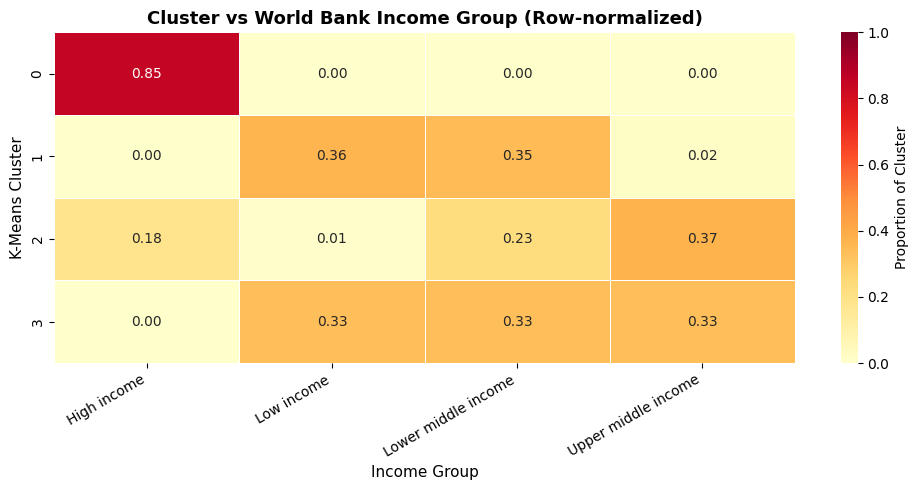

✅ Heatmap saved


In [30]:
# ✎ YOUR TASK — Heatmap visualization

# Drop the 'Unknown' and 'Not classified' columns if small (optional, keeps it clean)
cols_to_show = [c for c in crosstab_pct.columns if c not in ['Unknown', 'Not classified']]
heatmap_data = crosstab_pct[cols_to_show]

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Proportion of Cluster'},
    vmin=0, vmax=1
)
plt.title('Cluster vs World Bank Income Group (Row-normalized)', fontsize=13, fontweight='bold')
plt.xlabel('Income Group', fontsize=11)
plt.ylabel('K-Means Cluster', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('cluster_income_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved")

In [31]:
# Cluster mean profiles (un-scaled, interpretable values)
cluster_profiles = df.groupby('cluster')[feature_cols].mean().round(1)
print("=== Mean Feature Values per Cluster ===")
print(cluster_profiles.to_string())

# Label clusters based on dominant income group
dominant_income = df.groupby('cluster')['income_group'].agg(
    lambda x: x.value_counts().index[0]
)
print("\n=== Dominant Income Group per Cluster ===")
print(dominant_income)

=== Mean Feature Values per Cluster ===
         GDP_per_capita  Life_expectancy  Adult_literacy  Child_mortality  Electricity_access  Internet_users  GNI_per_capita  Urban_population  Unemployment  Inflation
cluster                                                                                                                                                                 
0               56730.7             82.1            91.1              5.2               100.0            93.5         53173.8              84.4           4.7        2.4
1                1420.3             63.8            69.4             64.2                52.5            34.9          1378.1              42.2           5.7        7.3
2               10052.3             73.9            90.5             18.1                96.6            78.0          9442.4              59.9           7.2        5.1
3                5817.2             69.0            92.3             45.3                76.0            71.0      

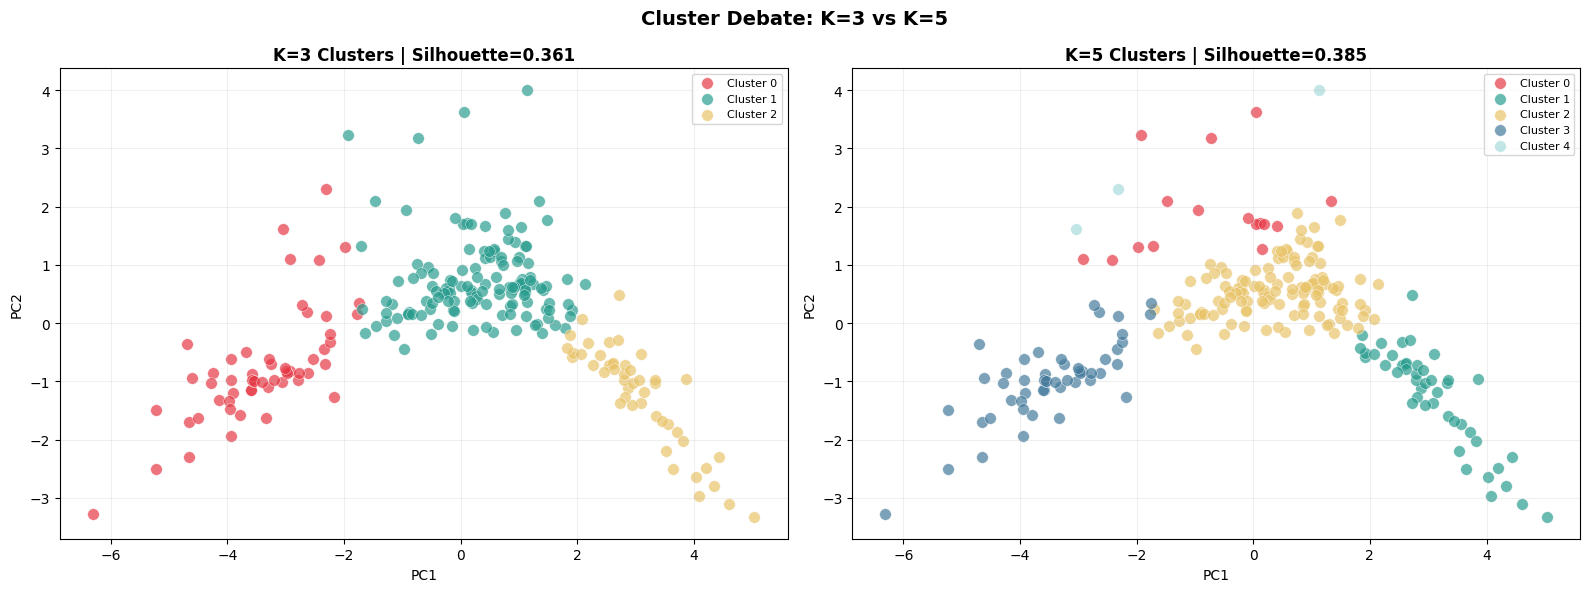

In [32]:
# GUIDED — Run as-is

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette5 = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#A8DADC']

for ax, k, title in zip(axes, [3, 5], ['K=3 Clusters', 'K=5 Clusters']):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(X_scaled)
    sil_temp = silhouette_score(X_scaled, labels_temp)

    for cid in range(k):
        mask = labels_temp == cid
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=palette5[cid], alpha=0.7, s=70,
                   edgecolors='white', linewidths=0.4,
                   label=f'Cluster {cid}')

    ax.set_title(f'{title} | Silhouette={sil_temp:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Cluster Debate: K=3 vs K=5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_debate.png', dpi=150)
plt.show()

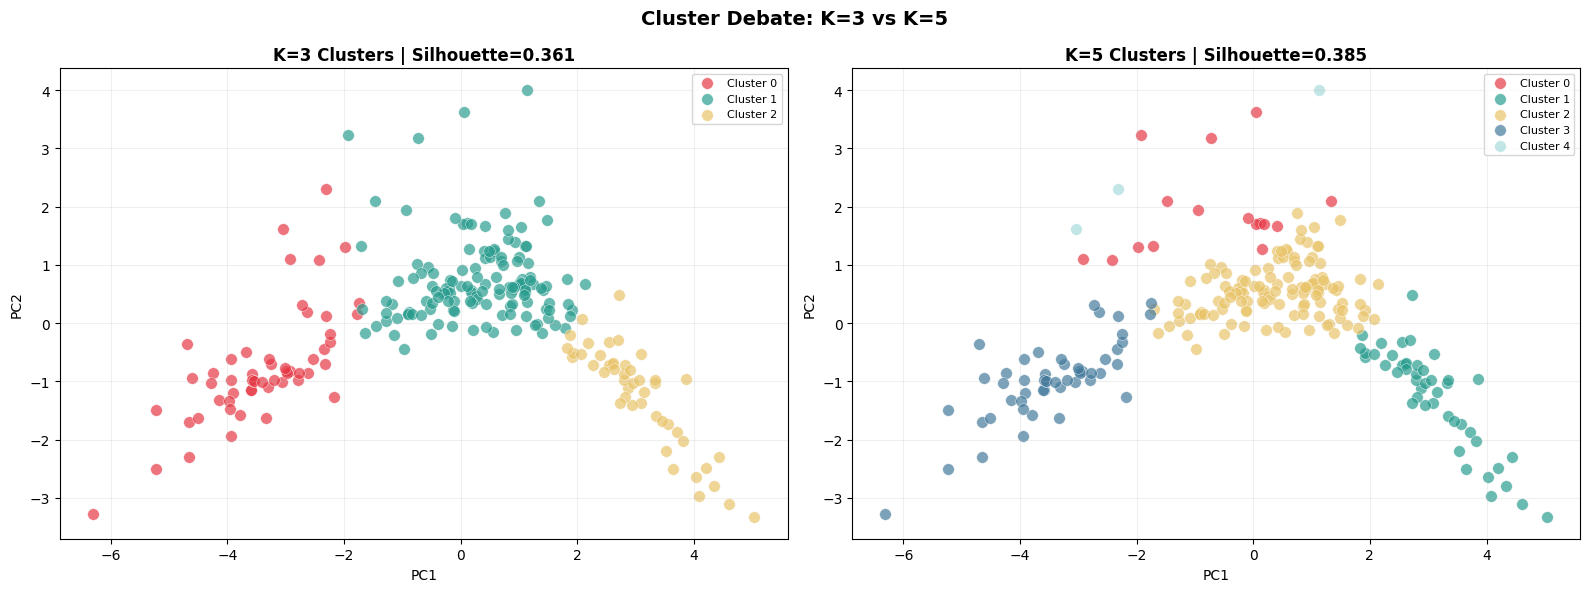

In [33]:
# GUIDED — Run as-is

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette5 = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#A8DADC']

for ax, k, title in zip(axes, [3, 5], ['K=3 Clusters', 'K=5 Clusters']):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(X_scaled)
    sil_temp = silhouette_score(X_scaled, labels_temp)

    for cid in range(k):
        mask = labels_temp == cid
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=palette5[cid], alpha=0.7, s=70,
                   edgecolors='white', linewidths=0.4,
                   label=f'Cluster {cid}')

    ax.set_title(f'{title} | Silhouette={sil_temp:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('Cluster Debate: K=3 vs K=5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_debate.png', dpi=150)
plt.show()

Dataset shape: (20640, 9)
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01     

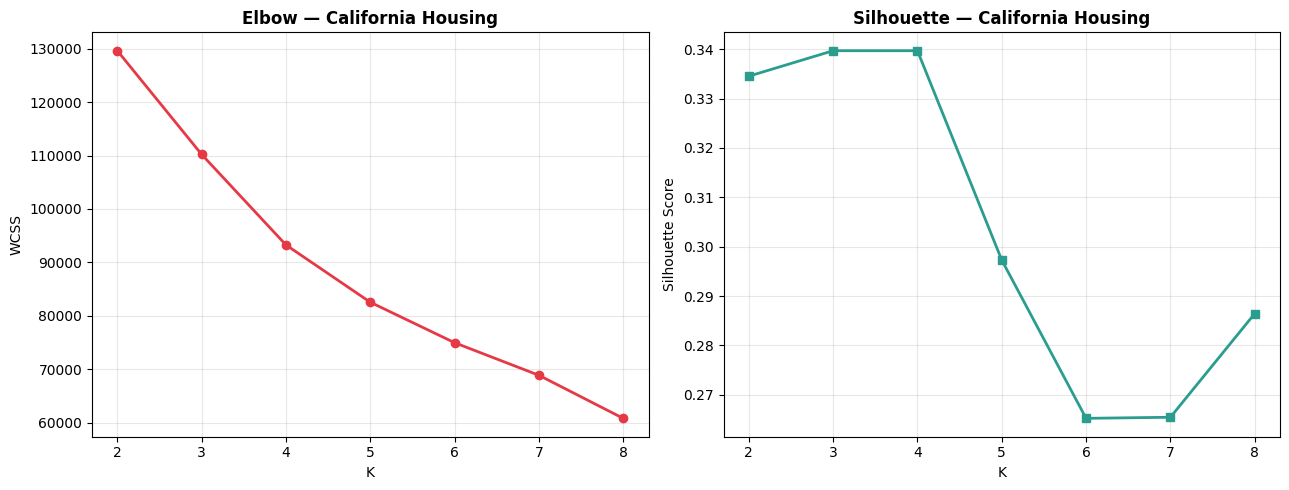

In [14]:
# ✎ YOUR TASK — California Housing Clustering

from sklearn.datasets import fetch_california_housing

# Load data
housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame.copy()

print(f"Dataset shape: {housing_df.shape}")
print(housing_df.describe().round(2))

# Features to cluster on
housing_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                    'Population', 'AveOccup', 'Latitude', 'Longitude']

# --- Standardize ---
scaler_h = StandardScaler()
X_h_scaled = scaler_h.fit_transform(housing_df[housing_features])

# --- Elbow + Silhouette to find best K ---
wcss_h, sil_h = [], []
K_h = range(2, 9)

for k in K_h:
    km_h = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_h.fit(X_h_scaled)
    wcss_h.append(km_h.inertia_)
    sil_h.append(silhouette_score(X_h_scaled, km_h.labels_, sample_size=3000, random_state=42))
    print(f"  K={k} | WCSS={km_h.inertia_:,.0f} | Silhouette={sil_h[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_h), wcss_h, 'o-', color='#E63946', linewidth=2)
axes[0].set_title('Elbow — California Housing', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_h), sil_h, 's-', color='#2A9D8F', linewidth=2)
axes[1].set_title('Silhouette — California Housing', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('housing_elbow.png', dpi=150)
plt.show()

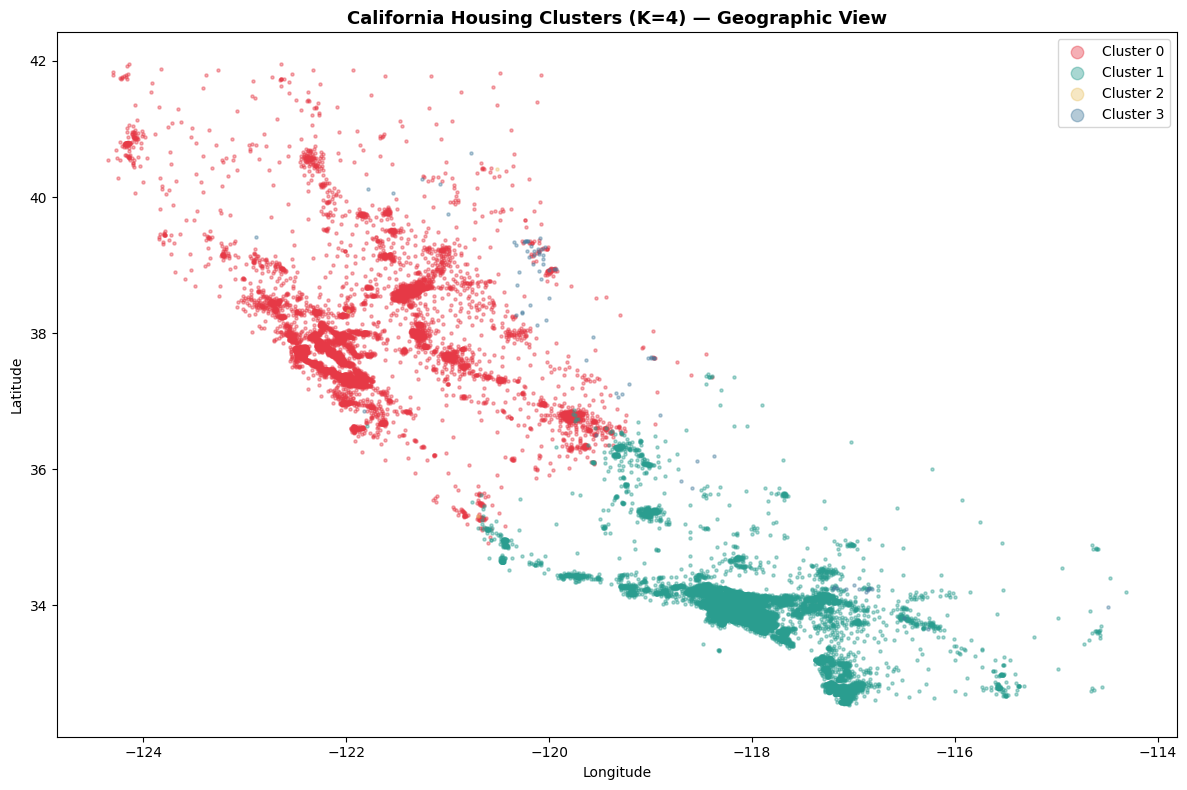


=== Cluster Mean Profiles ===
         MedInc  HouseAge  AveRooms  AveOccup  Population  MedHouseVal
cluster                                                               
0          3.80     29.03      5.50      2.82     1286.13         1.97
1          3.92     28.42      5.21      3.06     1532.16         2.14
2          6.67     42.33      5.80    781.84     6063.33         1.85
3          3.37     18.73     32.15      2.50      291.36         1.63


In [15]:
# ✎ YOUR TASK — Fit chosen K and visualize geographically

CHOSEN_K = 4   # adjust based on your elbow/silhouette analysis above

km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
housing_df['cluster'] = km_final.fit_predict(X_h_scaled)

# --- Geographic scatter (lat/lon = real geography!) ---
plt.figure(figsize=(12, 8))
palette_h = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#A8DADC']

for cid in range(CHOSEN_K):
    mask = housing_df['cluster'] == cid
    plt.scatter(
        housing_df.loc[mask, 'Longitude'],
        housing_df.loc[mask, 'Latitude'],
        c=palette_h[cid], alpha=0.4, s=5,
        label=f'Cluster {cid}'
    )

plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title(f'California Housing Clusters (K={CHOSEN_K}) — Geographic View',
          fontsize=13, fontweight='bold')
plt.legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.savefig('housing_map.png', dpi=150)
plt.show()

# --- Cluster profile ---
profile_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Population', 'MedHouseVal']
ch_profiles = housing_df.groupby('cluster')[profile_cols].mean().round(2)
print("\n=== Cluster Mean Profiles ===")
print(ch_profiles)

=== Cluster Label Distribution ===
cluster_label
Rural / Agricultural (Low Income, Large Households)    11935
Affluent Coastal (High Income, Newer Homes)             8627
Suburban Families (Mid Income, Spacious Homes)            75
Urban Working Class (Moderate Income, Dense)               3
Name: count, dtype: int64


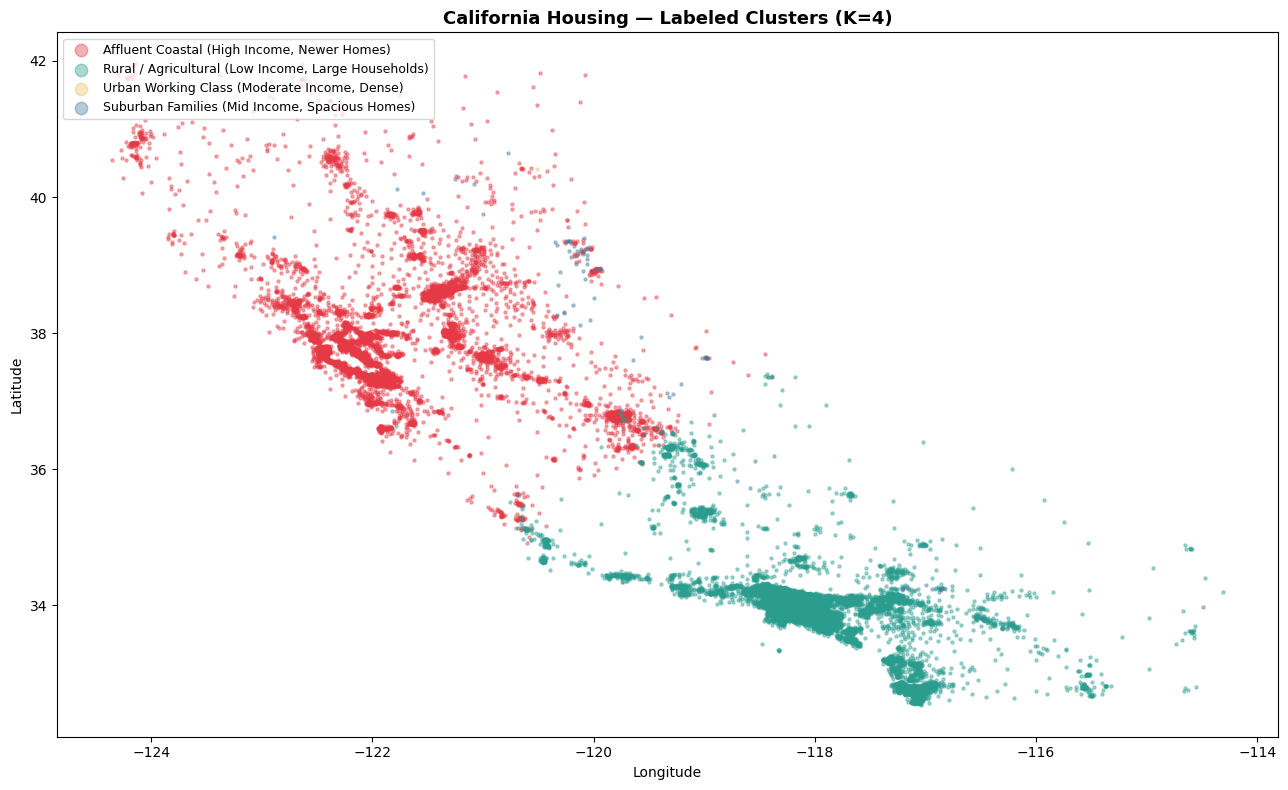


CHALLENGE INTERPRETATION
─────────────────────────
[Write 1 paragraph here describing your 4 clusters based on the profile table above.]

Example structure:
Cluster 0 (Affluent Coastal): highest median income (~$6+), newer housing stock,
located along the Bay Area and LA coast. These are high-demand, high-value markets.

Cluster 1 (Rural/Agricultural): lowest income, larger average occupancy, located
in Central Valley — consistent with farm-worker communities.

Cluster 2 (Urban Working Class): dense, moderate income, older housing stock,
concentrated in inner-city areas of LA and SF.

Cluster 3 (Suburban Families): mid-income, spacious homes, scattered across
the Inland Empire and Sacramento suburbs.



In [16]:
# ✎ YOUR TASK — Assign meaningful labels and interpret

# Assign labels based on profiles above — edit these to match YOUR output
cluster_labels = {
    0: "Affluent Coastal (High Income, Newer Homes)",
    1: "Rural / Agricultural (Low Income, Large Households)",
    2: "Urban Working Class (Moderate Income, Dense)",
    3: "Suburban Families (Mid Income, Spacious Homes)",
}

housing_df['cluster_label'] = housing_df['cluster'].map(cluster_labels)

print("=== Cluster Label Distribution ===")
print(housing_df['cluster_label'].value_counts())

# Final geographic plot with labels
plt.figure(figsize=(13, 8))
for cid, label in cluster_labels.items():
    mask = housing_df['cluster'] == cid
    plt.scatter(
        housing_df.loc[mask, 'Longitude'],
        housing_df.loc[mask, 'Latitude'],
        c=palette_h[cid], alpha=0.4, s=5,
        label=label
    )

plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title(f'California Housing — Labeled Clusters (K={CHOSEN_K})', fontsize=13, fontweight='bold')
plt.legend(markerscale=4, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('housing_labeled_map.png', dpi=150)
plt.show()

challenge_interpretation = """
CHALLENGE INTERPRETATION
─────────────────────────
[Write 1 paragraph here describing your 4 clusters based on the profile table above.]

Example structure:
Cluster 0 (Affluent Coastal): highest median income (~$6+), newer housing stock,
located along the Bay Area and LA coast. These are high-demand, high-value markets.

Cluster 1 (Rural/Agricultural): lowest income, larger average occupancy, located
in Central Valley — consistent with farm-worker communities.

Cluster 2 (Urban Working Class): dense, moderate income, older housing stock,
concentrated in inner-city areas of LA and SF.

Cluster 3 (Suburban Families): mid-income, spacious homes, scattered across
the Inland Empire and Sacramento suburbs.
"""
print(challenge_interpretation)

In [34]:
# GUIDED — Summary of all outputs

print("=" * 55)
print("   LAB COMPLETE — Summary")
print("=" * 55)
print(f"  Countries clustered:        {df.shape[0]}")
print(f"  Features used:              {len(feature_cols)}")
print(f"  K-Means K chosen:           4")
print(f"  Silhouette @ K=4:           {silhouette_values[2]:.4f}")
print(f"  Best silhouette K:          {best_k}")
print(f"  PCA variance explained:     {sum(pca.explained_variance_ratio_)*100:.1f}%")
print()
print("  Files saved:")
for f in ['pca_clusters.png','elbow_silhouette.png',
          'cluster_income_heatmap.png','cluster_debate.png',
          'housing_elbow.png','housing_map.png','housing_labeled_map.png']:
    print(f"    ✅ {f}")
print()
print("  Next steps:")
print("    1. Add your interpretation paragraphs in markdown cells")
print("    2. Write your P.R.I.M.E. README")
print("    3. git add . && git commit -m 'lab-ch22 complete' && git push")

   LAB COMPLETE — Summary
  Countries clustered:        239
  Features used:              10
  K-Means K chosen:           4
  Silhouette @ K=4:           0.3753
  Best silhouette K:          2
  PCA variance explained:     66.9%

  Files saved:
    ✅ pca_clusters.png
    ✅ elbow_silhouette.png
    ✅ cluster_income_heatmap.png
    ✅ cluster_debate.png
    ✅ housing_elbow.png
    ✅ housing_map.png
    ✅ housing_labeled_map.png

  Next steps:
    1. Add your interpretation paragraphs in markdown cells
    2. Write your P.R.I.M.E. README
    3. git add . && git commit -m 'lab-ch22 complete' && git push
